# Consumption analysis

## Overview

In [240]:
# to read datafile
import pandas as pd

# to use SQL queries
import duckdb as db

# to make simple charts
import matplotlib.pyplot as plt

In [241]:
# reads datafile in from another folder
households_electricity_consumption = pd.read_csv('../../DataSources/fictional_households_electricity_consumption_sorted.csv', sep = ";")
households_electricity_consumption

,household_id,timestamp,date,time,consumption_kwh
0,EE_APT_001,01.01.2023 12:00:00,01.01.2023,12:00:00,"0,1923"
1,EE_APT_001,02.01.2023 12:00:00,02.01.2023,12:00:00,"0,0872"
2,EE_APT_001,03.01.2023 12:00:00,03.01.2023,12:00:00,"0,1044"
3,EE_APT_001,04.01.2023 12:00:00,04.01.2023,12:00:00,"0,0929"
4,EE_APT_001,05.01.2023 12:00:00,05.01.2023,12:00:00,"0,089"
...,...,...,...,...,...
789025,EE_APT_001,27.12.2025 04:00:00,27.12.2025,04:00:00,"0,0336"
789026,EE_APT_001,28.12.2025 04:00:00,28.12.2025,04:00:00,"0,0334"
789027,EE_APT_001,29.12.2025 04:00:00,29.12.2025,04:00:00,"0,0315"
789028,EE_APT_001,30.12.2025 04:00:00,30.12.2025,04:00:00,"0,0278"


In [242]:
# overview of datafile values
db.sql("SUMMARIZE SELECT * FROM households_electricity_consumption")

┌─────────────────┬─────────────┬─────────────────────┬─────────────────────┬───────────────┬───────┬───────┬───────┬───────┬───────┬────────┬─────────────────┐
│   column_name   │ column_type │         min         │         max         │ approx_unique │  avg  │  std  │  q25  │  q50  │  q75  │ count  │ null_percentage │
│     varchar     │   varchar   │       varchar       │       varchar       │     int64     │ int32 │ int32 │ int32 │ int32 │ int32 │ int64  │  decimal(9,2)   │
├─────────────────┼─────────────┼─────────────────────┼─────────────────────┼───────────────┼───────┼───────┼───────┼───────┼───────┼────────┼─────────────────┤
│ household_id    │ VARCHAR     │ EE_APT_001          │ EE_SFH_010          │            31 │  NULL │  NULL │  NULL │  NULL │  NULL │ 789030 │            0.00 │
│ timestamp       │ VARCHAR     │ 01.01.2023 00:00:00 │ 31.12.2025 23:00:00 │         25368 │  NULL │  NULL │  NULL │  NULL │  NULL │ 789030 │            0.00 │
│ date            │ VARCHAR     │ 

In [243]:
# counts & names unique id-s
print(households_electricity_consumption['household_id'].unique())

<ArrowStringArray>
[  'EE_APT_001',   'EE_APT_002',   'EE_APT_003',   'EE_APT_004',
   'EE_APT_005',   'EE_APT_006',   'EE_APT_007',   'EE_APT_008',
   'EE_APT_009',   'EE_APT_010', 'EE_CONDO_001', 'EE_CONDO_002',
 'EE_CONDO_003', 'EE_CONDO_004', 'EE_CONDO_005',   'EE_SFH_001',
   'EE_SFH_002',   'EE_SFH_003',   'EE_SFH_004',   'EE_SFH_005',
   'EE_SFH_006',   'EE_SFH_007',   'EE_SFH_008',   'EE_SFH_009',
   'EE_SFH_010',   'EE_ROW_001',   'EE_ROW_002',   'EE_ROW_003',
   'EE_ROW_004',   'EE_ROW_005']
Length: 30, dtype: str


In [244]:
# changes timestamp from str to datetime
households_electricity_consumption['timestamp'] = pd.to_datetime(households_electricity_consumption['timestamp'], format='%d.%m.%Y %H:%M:%S')

# changes date from str to datetime
households_electricity_consumption['date'] = pd.to_datetime(households_electricity_consumption['date'], format='%d.%m.%Y')

# changes time from str to datetime
households_electricity_consumption['time'] = pd.to_datetime(households_electricity_consumption['time'], format='%H:%M:%S')

# changes consumption from str to float with decimal separator normalization
households_electricity_consumption['consumption_kwh'] = households_electricity_consumption['consumption_kwh'].str.replace(',', '.').astype(float)


In [245]:
# checks column datatypes
households_electricity_consumption.dtypes

household_id                  str
timestamp          datetime64[us]
date               datetime64[us]
time               datetime64[us]
consumption_kwh           float64
dtype: object

## Data aggregation

In [246]:
# aggregates consumption by year
consumption_per_year = db.query("""
    SELECT
        CAST(YEAR(date) AS INTEGER) AS year,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM households_electricity_consumption
    GROUP BY YEAR(date)
    ORDER BY year
""").df()

print(consumption_per_year)

   year  total_consumption_kwh
0  2023            259743.2051
1  2024            261115.7675
2  2025            259863.7615


In [247]:
# aggregates consumption by month
consumption_per_month = db.query("""
    SELECT
        CAST(month(date) AS INTEGER) AS month,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM households_electricity_consumption
    GROUP BY month(date)
    ORDER BY month
""").df()

print(consumption_per_month)

    month  total_consumption_kwh
0       1            128161.9247
1       2            109465.9106
2       3             87601.4007
3       4             47747.1336
4       5             27387.7305
5       6             23968.6863
6       7             23871.7413
7       8             24854.5420
8       9             33687.6963
9      10             59715.0571
10     11             96144.0003
11     12            118116.9107


In [248]:
# aggregates consumption by day
consumption_per_day = db.query("""
    SELECT
        CAST(day(date) AS INTEGER) AS day,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM households_electricity_consumption
    GROUP BY day(date)
    ORDER BY day
""").df()

print(consumption_per_day)

    day  total_consumption_kwh
0     1             25819.0807
1     2             25746.8264
2     3             25517.1854
3     4             25706.2170
4     5             25747.8378
5     6             25666.3377
6     7             25840.9566
7     8             25915.7723
8     9             25914.7769
9    10             25586.2902
10   11             25753.6646
11   12             25704.5689
12   13             25700.5645
13   14             25870.1596
14   15             25808.0905
15   16             25767.5306
16   17             25567.8819
17   18             25673.2931
18   19             25678.5724
19   20             25769.6177
20   21             25855.1934
21   22             25836.5943
22   23             25696.7289
23   24             25588.5720
24   25             25660.7279
25   26             25697.7563
26   27             25710.0190
27   28             25822.9894
28   29             23220.0341
29   30             21826.7994
30   31             15052.0946


In [249]:
# aggregates consumption by hour
consumption_per_hour = db.query("""
    SELECT
        CAST(hour(time) AS INTEGER) AS hour,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM households_electricity_consumption
    GROUP BY hour(time)
    ORDER BY hour
""").df()

print(consumption_per_hour)

    hour  total_consumption_kwh
0      0             26071.2834
1      1             25234.2390
2      2             24955.2644
3      3             24196.2008
4      4             24324.9739
5      5             26497.2390
6      6             32886.1955
7      7             31471.0929
8      8             29767.6309
9      9             28582.8928
10    10             28460.5836
11    11             28479.1466
12    12             30126.3087
13    13             28787.3032
14    14             28144.1497
15    15             28939.7765
16    16             32143.5337
17    17             39765.7633
18    18             49203.5731
19    19             50259.0608
20    20             47544.6588
21    21             44280.4373
22    22             39412.2291
23    23             31189.1971


In [250]:
# aggregates consumption by household_id
consumption_per_household = db.query("""
    SELECT
        household_id AS household,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM households_electricity_consumption
    GROUP BY household
    ORDER BY household ASC
""").df()

print(consumption_per_household)

       household  total_consumption_kwh
0     EE_APT_001              1930.8726
1     EE_APT_002              3858.3411
2     EE_APT_003              4720.2520
3     EE_APT_004              7863.4135
4     EE_APT_005             16489.8110
5     EE_APT_006               867.1437
6     EE_APT_007             15683.5800
7     EE_APT_008              3281.4452
8     EE_APT_009             19833.1958
9     EE_APT_010              2103.3739
10  EE_CONDO_001              6024.3538
11  EE_CONDO_002             14850.0774
12  EE_CONDO_003              2702.0456
13  EE_CONDO_004             22486.2683
14  EE_CONDO_005              7984.9102
15    EE_ROW_001             11277.4174
16    EE_ROW_002             23127.5625
17    EE_ROW_003             30059.7114
18    EE_ROW_004              8494.8682
19    EE_ROW_005             10961.9379
20    EE_SFH_001             28643.4365
21    EE_SFH_002             50098.7058
22    EE_SFH_003             98691.3972
23    EE_SFH_004             72109.7610


## Simple graphs

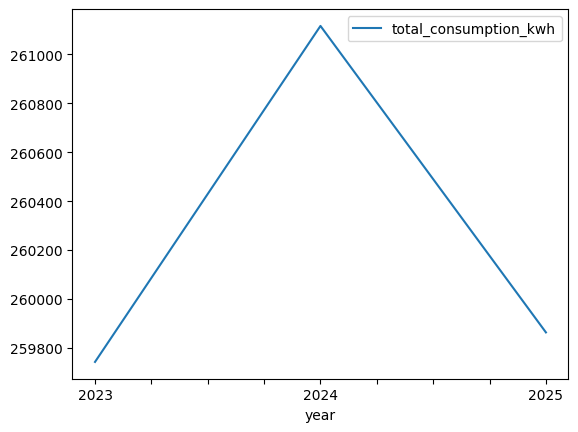

In [251]:
# consumption by year graph, converting year into a discrete category / matplot
ax = consumption_per_year.assign(year=consumption_per_year['year'].astype(str)).plot(
    x="year", y="total_consumption_kwh", kind="line")

Text(0, 0.5, 'Total consumption (kWh)')

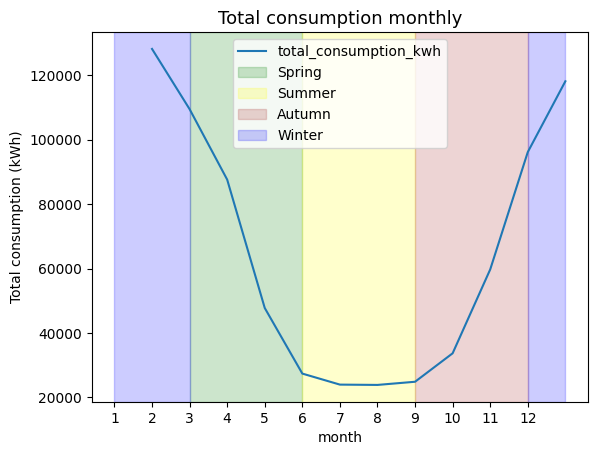

In [256]:
# consumption by month graph / matplot
ax = consumption_per_month.plot(
    x="month", y="total_consumption_kwh", kind="line")

# defines the amount of x axis points
ax.set_xticks(range(12))

# defines the labels on x axis points
ax.set_xticklabels(range(1, 13))

# defines seasons / st-ni
spring_start = 2
spring_end = 5
summer_start = 5
summer_end = 8
autumn_start = 8
autumn_end = 11
winter_start = 11
winter_end = 2

# adds a light color for spring
ax.axvspan(spring_start, spring_end, alpha=0.2, color='green', label='Spring')

# adds a light color for summer
ax.axvspan(summer_start, summer_end, alpha=0.2, color='yellow', label='Summer')

# adds a light color for autumn
ax.axvspan(autumn_start, autumn_end, alpha=0.2, color='brown', label='Autumn')

# adds a light color for winter
ax.axvspan(winter_start, 12, alpha=0.2, color='blue', label = 'Winter')
ax.axvspan(0, winter_end, alpha=0.2, color='blue')

# adds a legend
ax.legend()

# adds a title to the graph
ax.set_title("Total consumption monthly", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")


[Text(0, 0, '1'),
 Text(1, 0, '2'),
 Text(2, 0, '3'),
 Text(3, 0, '4'),
 Text(4, 0, '5'),
 Text(5, 0, '6'),
 Text(6, 0, '7'),
 Text(7, 0, '8'),
 Text(8, 0, '9'),
 Text(9, 0, '10'),
 Text(10, 0, '11'),
 Text(11, 0, '12'),
 Text(12, 0, '13'),
 Text(13, 0, '14'),
 Text(14, 0, '15'),
 Text(15, 0, '16'),
 Text(16, 0, '17'),
 Text(17, 0, '18'),
 Text(18, 0, '19'),
 Text(19, 0, '20'),
 Text(20, 0, '21'),
 Text(21, 0, '22'),
 Text(22, 0, '23'),
 Text(23, 0, '24'),
 Text(24, 0, '25'),
 Text(25, 0, '26'),
 Text(26, 0, '27'),
 Text(27, 0, '28'),
 Text(28, 0, '29'),
 Text(29, 0, '30'),
 Text(30, 0, '31')]

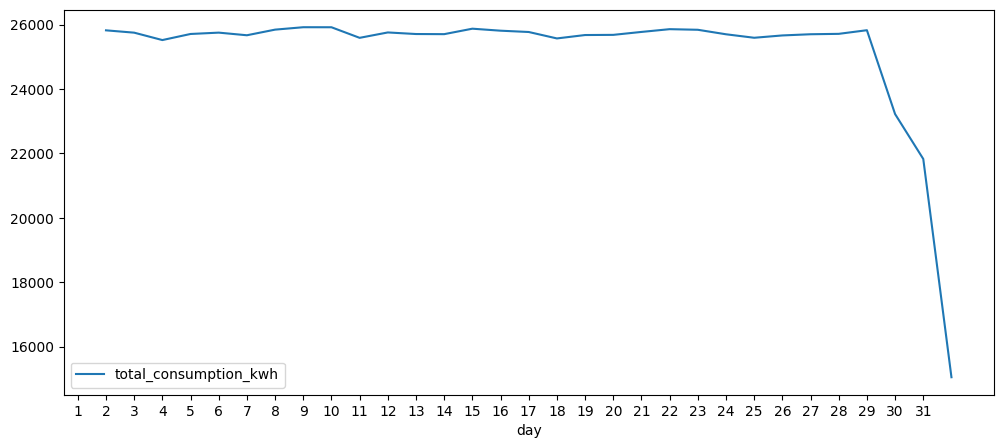

In [253]:
# consumption by day graph / matplot
ax = consumption_per_day.plot(
    x="day", y="total_consumption_kwh", kind="line", figsize=[12,5])

# defines the amount of x axis points
ax.set_xticks(range(31))

# defines the labels on x axis points
ax.set_xticklabels(range(1, 32))

Text(0, 0.5, 'Total consumption (kWh)')

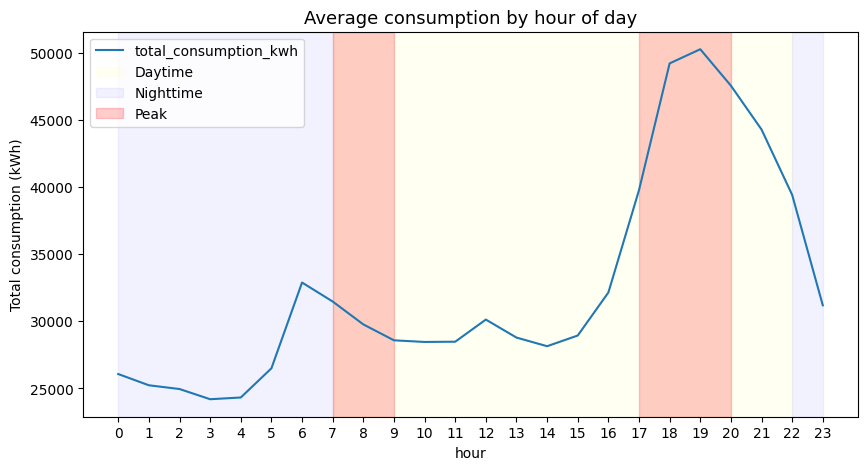

In [254]:
# consumption by hour graph / matplot
ax = consumption_per_hour.plot(
    x="hour", y="total_consumption_kwh", kind="line", figsize=[10,5])

# defines the amount of x axis points
ax.set_xticks(range(24))

# defines the labels on x axis points
ax.set_xticklabels(range(0, 24))

# defines daytime and nighttime
day_start = 7
night_start = 22

# adds a light color for daytime
ax.axvspan(day_start, night_start, alpha=0.05, color='yellow', label='Daytime')

# adds a light color for nighttime
ax.axvspan(0, day_start, alpha=0.05, color='blue', label='Nighttime')
ax.axvspan(night_start, 23, alpha=0.05, color='blue')

# defines peak hours
morning_peak_start = 7
morning_peak_end = 9
evening_peak_start = 17
evening_peak_end = 20

# adds a light color for peak times in the morning and evening
ax.axvspan(morning_peak_start, morning_peak_end, alpha=0.2, color='red', label='Peak')
ax.axvspan(evening_peak_start, evening_peak_end, alpha=0.2, color='red')

# adds a legend
ax.legend()

# adds a title to the graph
ax.set_title("Average consumption by hour of day", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")


30

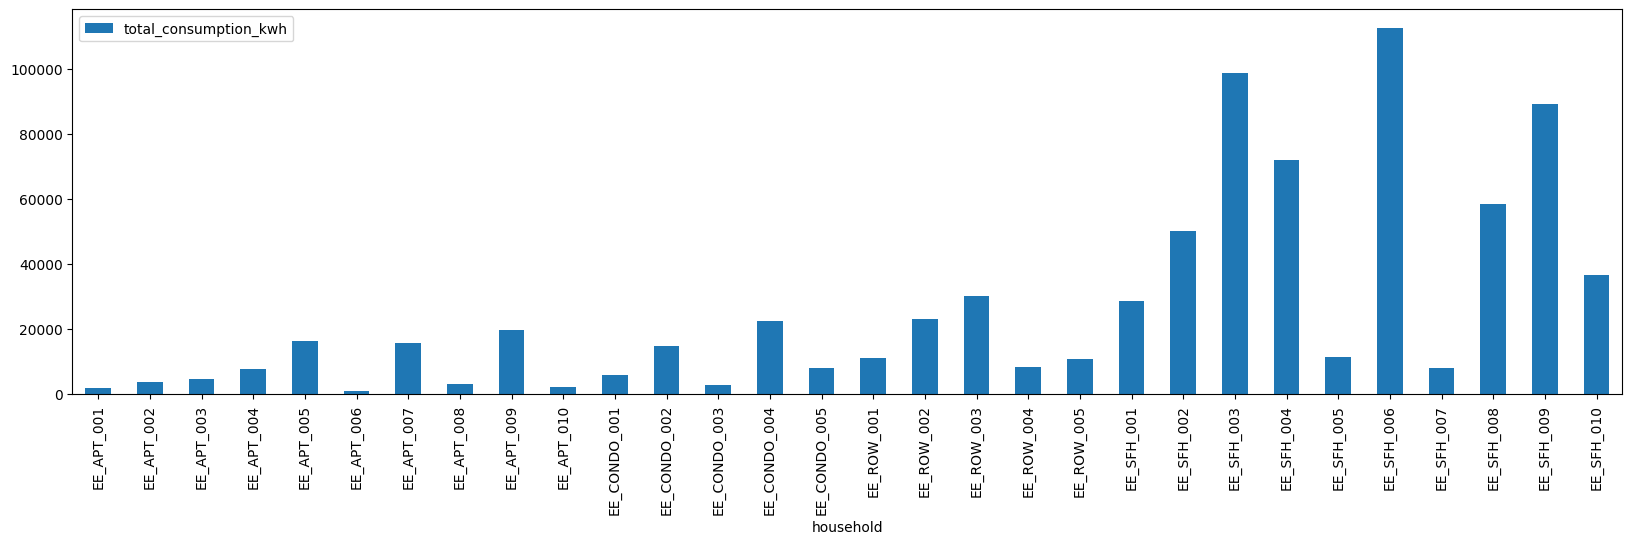

In [255]:
# consumption by household bar chart / matplot
ax = consumption_per_household.plot(
    x="household", y="total_consumption_kwh", kind="bar", figsize=(20, 5))

# counts the x axis points
len(ax.get_xticks())